In [ ]:
from google.colab import drive
drive.mount('/content/drive')

Mounted at /content/drive


In [ ]:
import os

root = "/content/drive/My Drive"
print(os.listdir(root))

['class 12..pdf', 'Colab Notebooks', 'Lab Assignment 2 (Arrays cont.).gdoc', '3-Encapsulation.gdoc', 'L1 (3).gdoc', 'L1 (2).gdoc', 'L1 (1).gdoc', 'L1.gdoc', 'Document from Diya Saini (2)', 'Document from Diya Saini (1)', 'Probability Distributions and Concepts Cheat Sheet.gdoc', 'Untitled document.gdoc', 'RESUME (6) (2).pdf', 'RESUME (6) (1).pdf', 'RESUME (6).pdf', 'Document from Diya Saini', 'Resume_Diya (2).pdf', 'Resume_Diya (1).pdf', 'Resume_Diya.pdf', 'archive', 'HAM10000_binary']


In [ ]:
archive_dir = "/content/drive/My Drive/archive"
print(len(os.listdir(archive_dir)))
print(os.listdir(archive_dir)[:10])  # show first 10 items

7
['HAM10000_metadata.csv', 'hmnist_28_28_L.csv', 'hmnist_8_8_L.csv', 'hmnist_28_28_RGB.csv', 'hmnist_8_8_RGB.csv', 'HAM10000_images_part_2', 'HAM10000_images_part_1']


In [ ]:
import os

# List all folders in your Drive root
print("Files in Drive root:")
print(os.listdir("/content/drive/My Drive/"))

print("\n" + "="*50)

# Check common locations
possible_paths = [
    "/content/drive/My Drive/IMG0000_binary",
    "/content/drive/My Drive/archive/IMG0000_binary",
    "/content/drive/My Drive/Colab Notebooks/IMG0000_binary",
]

for path in possible_paths:
    if os.path.exists(path):
        print(f"✓ Found dataset at: {path}")
        print(f"  Contents: {os.listdir(path)[:5]}")  # Show first 5 items
    else:
        print(f"✗ Not found: {path}")

Files in Drive root:
['class 12..pdf', 'Colab Notebooks', 'Lab Assignment 2 (Arrays cont.).gdoc', '3-Encapsulation.gdoc', 'L1 (3).gdoc', 'L1 (2).gdoc', 'L1 (1).gdoc', 'L1.gdoc', 'Document from Diya Saini (2)', 'Document from Diya Saini (1)', 'Probability Distributions and Concepts Cheat Sheet.gdoc', 'Untitled document.gdoc', 'RESUME (6) (2).pdf', 'RESUME (6) (1).pdf', 'RESUME (6).pdf', 'Document from Diya Saini', 'Resume_Diya (2).pdf', 'Resume_Diya (1).pdf', 'Resume_Diya.pdf', 'archive', 'HAM10000_binary']

✗ Not found: /content/drive/My Drive/IMG0000_binary
✗ Not found: /content/drive/My Drive/archive/IMG0000_binary
✗ Not found: /content/drive/My Drive/Colab Notebooks/IMG0000_binary


In [ ]:
import os
import shutil
import pandas as pd

# Paths in Drive
root_dir      = "/content/drive/My Drive/archive"
metadata_csv  = os.path.join(root_dir, "HAM10000_metadata.csv")
images_dir_1  = os.path.join(root_dir, "HAM10000_images_part_1")
images_dir_2  = os.path.join(root_dir, "HAM10000_images_part_2")

# Output folder for ImageFolder
output_root   = "/content/drive/My Drive/HAM10000_binary"
benign_dir    = os.path.join(output_root, "benign")
malignant_dir = os.path.join(output_root, "malignant")

os.makedirs(benign_dir, exist_ok=True)
os.makedirs(malignant_dir, exist_ok=True)

# Label mapping (7 classes -> 2)
malignant_labels = {"mel", "bcc", "akiec"}
benign_labels    = {"nv", "bkl", "df", "vasc"}

# Read metadata
df = pd.read_csv(metadata_csv)

missing = 0

for _, row in df.iterrows():
    image_id = row["image_id"]  # e.g., 'ISIC_0024306'
    label    = row["dx"]        # e.g., 'mel', 'nv', etc.

    # Decide target folder
    if label in malignant_labels:
        dst_dir = malignant_dir
    elif label in benign_labels:
        dst_dir = benign_dir
    else:
        print("Unknown label:", label)
        continue

    filename = image_id + ".jpg"

    # Look for the file in part_1 or part_2
    src1 = os.path.join(images_dir_1, filename)
    src2 = os.path.join(images_dir_2, filename)

    if os.path.exists(src1):
        src = src1
    elif os.path.exists(src2):
        src = src2
    else:
        missing += 1
        print("Missing image:", filename)
        continue

    dst = os.path.join(dst_dir, filename)

    if not os.path.exists(dst):
        shutil.copy2(src, dst)

print("Done organizing.")
print("Benign images:", len(os.listdir(benign_dir)))
print("Malignant images:", len(os.listdir(malignant_dir)))
print("Missing images:", missing)

Done organizing.
Benign images: 8061
Malignant images: 1954
Missing images: 0


In [ ]:
# Install any missing libraries
!pip install torch torchvision matplotlib seaborn scikit-learn tqdm

# Import everything
import torch
import torch.nn as nn
import torch.optim as optim
from torch.utils.data import DataLoader, random_split
from torchvision import datasets, transforms, models
import matplotlib.pyplot as plt
import numpy as np
from tqdm import tqdm
import seaborn as sns

print("All libraries imported successfully!")
print(f"PyTorch version: {torch.__version__}")
print(f"GPU Available: {torch.cuda.is_available()}")

All libraries imported successfully!
PyTorch version: 2.10.0+cu128
GPU Available: True


In [ ]:
# Check if GPU is enabled
device = torch.device("cuda" if torch.cuda.is_available() else "cpu")
print(f"Using device: {device}")

if device.type == "cuda":
    print(f"✓ GPU Name: {torch.cuda.get_device_name(0)}")
    print(f"✓ GPU Memory: {torch.cuda.get_device_properties(0).total_memory / 1e9:.2f} GB")
    print("✓ Ready for fast training!")
else:
    print("❌ GPU still not detected - please check runtime settings")

Using device: cuda
✓ GPU Name: Tesla T4
✓ GPU Memory: 15.64 GB
✓ Ready for fast training!


In [ ]:
from PIL import Image
import os

data_dir = "/content/drive/My Drive/HAM10000_binary/"
corrupted_images = []

# Check all images in benign and malignant folders
for class_name in ['benign', 'malignant']:
    class_path = os.path.join(data_dir, class_name)
    for img_file in os.listdir(class_path):
        if img_file.endswith('.jpg'):
            img_path = os.path.join(class_path, img_file)
            try:
                img = Image.open(img_path)
                img.verify()  # Verify image integrity
            except Exception as e:
                corrupted_images.append(img_path)
                print(f"❌ Corrupted: {img_path}")

print(f"\n{'='*50}")
print(f"Found {len(corrupted_images)} corrupted images")

if len(corrupted_images) > 0:
    print("\nCorrupted files:")
    for img in corrupted_images:
        print(f"  - {img}")

❌ Corrupted: /content/drive/My Drive/HAM10000_binary/malignant/ISIC_0026154.jpg

Found 1 corrupted images

Corrupted files:
  - /content/drive/My Drive/HAM10000_binary/malignant/ISIC_0026154.jpg


In [ ]:
import os

# Path to corrupted image
corrupted_path = "/content/drive/My Drive/HAM10000_binary/malignant/ISIC_0026154.jpg"

# Remove the file
try:
    os.remove(corrupted_path)
    print(f"✓ Removed: {corrupted_path}")
    print(f"✅ Corrupted image successfully deleted!")
except Exception as e:
    print(f"Error: {e}")

# Verify it's gone
if not os.path.exists(corrupted_path):
    print(f"\n✓ Confirmed: File no longer exists")
else:
    print(f"\n⚠️ File still exists - please remove manually")

✓ Removed: /content/drive/My Drive/HAM10000_binary/malignant/ISIC_0026154.jpg
✅ Corrupted image successfully deleted!

✓ Confirmed: File no longer exists


In [ ]:
from torch.utils.data import DataLoader, random_split
from torchvision import datasets, transforms
import torch
import os

data_dir = "/content/drive/My Drive/HAM10000_binary/"

# Define transforms
train_transform = transforms.Compose([
    transforms.Resize((224, 224)),
    transforms.RandomHorizontalFlip(p=0.5),
    transforms.RandomRotation(10),
    transforms.ToTensor(),
    transforms.Normalize(mean=[0.485, 0.456, 0.406],
                         std=[0.229, 0.224, 0.225])
])

test_transform = transforms.Compose([
    transforms.Resize((224, 224)),
    transforms.ToTensor(),
    transforms.Normalize(mean=[0.485, 0.456, 0.406],
                         std=[0.229, 0.224, 0.225])
])

# Load clean dataset (fast - no looping)
full_dataset = datasets.ImageFolder(root=data_dir, transform=train_transform)

print("✓ CLEAN DATASET LOADED!")
print("="*40)
print(f"Total images: {len(full_dataset)}")
print(f"Classes: {full_dataset.classes}")

# Quick count using os (much faster than looping)
benign_count = len(os.listdir(os.path.join(data_dir, "benign")))
malignant_count = len(os.listdir(os.path.join(data_dir, "malignant")))

print(f"  Benign: {benign_count} images")
print(f"  Malignant: {malignant_count} images")

# Split dataset
train_size = int(0.7 * len(full_dataset))
val_size = int(0.15 * len(full_dataset))
test_size = len(full_dataset) - train_size - val_size

print(f"\n✓ DATA SPLIT:")
print(f"  Training: {train_size} images")
print(f"  Validation: {val_size} images")
print(f"  Test: {test_size} images")

# Create splits
train_dataset, val_dataset, test_dataset = random_split(full_dataset, [train_size, val_size, test_size])

# Apply transforms
val_dataset.dataset.transform = test_transform
test_dataset.dataset.transform = test_transform

# Create DataLoaders
batch_size = 64
train_loader = DataLoader(train_dataset, batch_size=batch_size, shuffle=True, num_workers=2, pin_memory=True)
val_loader = DataLoader(val_dataset, batch_size=batch_size, shuffle=False, num_workers=2, pin_memory=True)
test_loader = DataLoader(test_dataset, batch_size=batch_size, shuffle=False, num_workers=2, pin_memory=True)

print("\n✓ DATALOADERS READY")
print("="*40)
print(f"Training batches: {len(train_loader)}")
print(f"Validation batches: {len(val_loader)}")
print(f"Test batches: {len(test_loader)}")
print(f"Batch size: {batch_size}")

✓ CLEAN DATASET LOADED!
Total images: 10014
Classes: ['benign', 'malignant']
  Benign: 8061 images
  Malignant: 1953 images

✓ DATA SPLIT:
  Training: 7009 images
  Validation: 1502 images
  Test: 1503 images

✓ DATALOADERS READY
Training batches: 110
Validation batches: 24
Test batches: 24
Batch size: 64


In [ ]:
import torch.nn as nn
import torch.optim as optim
from torchvision import models

# Reset model for fresh training
model = models.resnet34(weights=models.ResNet34_Weights.IMAGENET1K_V1)
model.fc = nn.Linear(model.fc.in_features, 2)
model = model.to(device)

# Training components
criterion = nn.CrossEntropyLoss()
optimizer = optim.Adam(model.parameters(), lr=0.001)
scheduler = optim.lr_scheduler.ReduceLROnPlateau(optimizer, mode='min', patience=3, factor=0.5)

print("✓ Model ready for training!")
print(f"  Device: {device}")
print(f"  Model parameters: {sum(p.numel() for p in model.parameters()):,}")

✓ Model ready for training!
  Device: cuda
  Model parameters: 21,285,698


In [ ]:
# Loss function for binary classification
criterion = nn.CrossEntropyLoss()

# Optimizer (Adam is good for baseline)
optimizer = optim.Adam(model.parameters(), lr=0.001)

# Learning rate scheduler (reduces LR when validation loss plateaus)
scheduler = optim.lr_scheduler.ReduceLROnPlateau(optimizer, mode='min', patience=3, factor=0.5)

print("✓ Training components ready:")
print(f"  Loss: CrossEntropyLoss")
print(f"  Optimizer: Adam (learning rate = 0.001)")
print(f"  Scheduler: ReduceLROnPlateau (patience=3)")


✓ Training components ready:
  Loss: CrossEntropyLoss
  Optimizer: Adam (learning rate = 0.001)
  Scheduler: ReduceLROnPlateau (patience=3)


In [ ]:
from tqdm import tqdm

def train_one_epoch(model, train_loader, criterion, optimizer, device):
    model.train()
    running_loss = 0.0
    correct = 0
    total = 0

    for images, labels in tqdm(train_loader, desc="Training"):
        images, labels = images.to(device), labels.to(device)

        # Forward pass
        outputs = model(images)
        loss = criterion(outputs, labels)

        # Backward pass
        optimizer.zero_grad()
        loss.backward()
        optimizer.step()

        # Statistics
        running_loss += loss.item()
        _, predicted = outputs.max(1)
        total += labels.size(0)
        correct += predicted.eq(labels).sum().item()

    epoch_loss = running_loss / len(train_loader)
    epoch_acc = 100. * correct / total

    return epoch_loss, epoch_acc

def validate(model, val_loader, criterion, device):
    model.eval()
    running_loss = 0.0
    correct = 0
    total = 0

    with torch.no_grad():
        for images, labels in tqdm(val_loader, desc="Validation"):
            images, labels = images.to(device), labels.to(device)
            outputs = model(images)
            loss = criterion(outputs, labels)

            running_loss += loss.item()
            _, predicted = outputs.max(1)
            total += labels.size(0)
            correct += predicted.eq(labels).sum().item()

    epoch_loss = running_loss / len(val_loader)
    epoch_acc = 100. * correct / total

    return epoch_loss, epoch_acc

print("✓ Training and validation functions defined (fixed version)")

✓ Training and validation functions defined (fixed version)


In [ ]:
# Quick verification
print("Checking DataLoaders...")
print(f"Train loader: {len(train_loader)} batches")
print(f"Val loader: {len(val_loader)} batches")
print(f"Test loader: {len(test_loader)} batches")
print(f"Model device: {next(model.parameters()).device}")
print(f"✅ Ready to train!")


Checking DataLoaders...
Train loader: 110 batches
Val loader: 24 batches
Test loader: 24 batches
Model device: cuda:0
✅ Ready to train!


In [ ]:
# Make sure everything is ready
if 'train_loader' not in dir():
    print("❌ Error: train_loader not found! Run Step 3 first.")
else:
    print(f"✓ train_loader found: {len(train_loader)} batches")
    print(f"✓ val_loader found: {len(val_loader)} batches")
    print(f"✓ Model on: {next(model.parameters()).device}")
    print("\nStarting training...\n")

# Training settings
num_epochs = 10
train_losses, val_losses, train_accs, val_accs = [], [], [], []
best_val_acc = 0

print("🚀 BASELINE RESNET34 TRAINING")
print("="*50)
print(f"Total epochs: {num_epochs}")
print(f"Training images: 7,010")
print(f"Validation images: 1,502")
print(f"Batch size: 64")
print(f"Device: {device}")
print("="*50)

for epoch in range(num_epochs):
    print(f"\n🔄 Epoch {epoch+1}/{num_epochs}")

    # Train
    train_loss, train_acc = train_one_epoch(model, train_loader, criterion, optimizer, device)
    train_losses.append(train_loss)
    train_accs.append(train_acc)

    # Validate
    val_loss, val_acc = validate(model, val_loader, criterion, device)
    val_losses.append(val_loss)
    val_accs.append(val_acc)

    # Update learning rate scheduler
    scheduler.step(val_loss)

    # Save best model
    if val_acc > best_val_acc:
        best_val_acc = val_acc
        torch.save(model.state_dict(), '/content/best_baseline_model.pth')
        print(f"  ⭐ NEW BEST MODEL! Val Acc: {val_acc:.2f}%")

    # Summary
    print(f"  📊 Train Loss: {train_loss:.4f} | Train Acc: {train_acc:.2f}%")
    print(f"  📊 Val Loss:   {val_loss:.4f} | Val Acc:   {val_acc:.2f}%")
    print(f"  🏆 Best Val Acc: {best_val_acc:.2f}%")
    print(f"  📉 Learning Rate: {optimizer.param_groups[0]['lr']:.6f}")

print("\n" + "="*50)
print("✅ BASELINE TRAINING COMPLETE!")
print(f"🏆 Best Validation Accuracy: {best_val_acc:.2f}%")
print("💾 Best model saved at: /content/best_baseline_model.pth")

✓ train_loader found: 110 batches
✓ val_loader found: 24 batches
✓ Model on: cuda:0

Starting training...

🚀 BASELINE RESNET34 TRAINING
Total epochs: 10
Training images: 7,010
Validation images: 1,502
Batch size: 64
Device: cuda

🔄 Epoch 1/10


Validation: 100%|██████████| 24/24 [00:33<00:00,  1.42s/it]


  ⭐ NEW BEST MODEL! Val Acc: 84.15%
  📊 Train Loss: 0.3574 | Train Acc: 82.19%
  📊 Val Loss:   0.3482 | Val Acc:   84.15%
  🏆 Best Val Acc: 84.15%
  📉 Learning Rate: 0.001000

🔄 Epoch 2/10


Validation: 100%|██████████| 24/24 [00:16<00:00,  1.45it/s]


  ⭐ NEW BEST MODEL! Val Acc: 84.42%
  📊 Train Loss: 0.3414 | Train Acc: 83.84%
  📊 Val Loss:   0.3252 | Val Acc:   84.42%
  🏆 Best Val Acc: 84.42%
  📉 Learning Rate: 0.001000

🔄 Epoch 3/10


...

  📊 Train Loss: 0.2613 | Train Acc: 88.66%
  📊 Val Loss:   0.3025 | Val Acc:   86.22%
  🏆 Best Val Acc: 86.42%
  📉 Learning Rate: 0.001000

🔄 Epoch 9/10


Validation: 100%|██████████| 24/24 [00:17<00:00,  1.41it/s]


  📊 Train Loss: 0.2468 | Train Acc: 89.21%
  📊 Val Loss:   0.3163 | Val Acc:   86.28%
  🏆 Best Val Acc: 86.42%
  📉 Learning Rate: 0.001000

🔄 Epoch 10/10


Validation: 100%|██████████| 24/24 [00:16<00:00,  1.43it/s]

  📊 Train Loss: 0.2227 | Train Acc: 90.75%
  📊 Val Loss:   0.3601 | Val Acc:   86.02%
  🏆 Best Val Acc: 86.42%
  📉 Learning Rate: 0.001000

✅ BASELINE TRAINING COMPLETE!
🏆 Best Validation Accuracy: 86.42%
💾 Best model saved at: /content/best_baseline_model.pth


In [ ]:
# Load best model
model.load_state_dict(torch.load('/content/best_baseline_model.pth'))

# Test evaluation
model.eval()
correct = 0
total = 0
all_preds = []
all_labels = []

print("📊 TESTING BASELINE MODEL")
print("="*40)

with torch.no_grad():
    for images, labels in tqdm(test_loader, desc="Testing"):
        images, labels = images.to(device), labels.to(device)
        outputs = model(images)
        _, predicted = outputs.max(1)
        total += labels.size(0)
        correct += predicted.eq(labels).sum().item()

        all_preds.extend(predicted.cpu().numpy())
        all_labels.extend(labels.cpu().numpy())

test_acc = 100. * correct / total

print("\n" + "="*40)
print("📊 BASELINE MODEL RESULTS")
print("="*40)
print(f"Test Accuracy: {test_acc:.2f}%")
print(f"Total test samples: {total}")
print(f"Correct predictions: {correct}")
print(f"Wrong predictions: {total - correct}")

# Per-class accuracy
from sklearn.metrics import classification_report, confusion_matrix
print("\n📋 Per-class performance:")
print(classification_report(all_labels, all_preds, target_names=['Benign', 'Malignant']))

# Confusion matrix
cm = confusion_matrix(all_labels, all_preds)
print("\n📊 Confusion Matrix:")
print(f"                 Predicted")
print(f"                 Benign  Malignant")
print(f"Actual Benign    {cm[0,0]:5d}   {cm[0,1]:5d}")
print(f"       Malignant  {cm[1,0]:5d}   {cm[1,1]:5d}")

📊 TESTING BASELINE MODEL


Testing: 100%|██████████| 24/24 [00:43<00:00,  1.79s/it]



📊 BASELINE MODEL RESULTS
Test Accuracy: 83.03%
Total test samples: 1503
Correct predictions: 1248
Wrong predictions: 255

📋 Per-class performance:
              precision    recall  f1-score   support

      Benign       0.85      0.95      0.90      1192
   Malignant       0.67      0.36      0.47       311

    accuracy                           0.83      1503
   macro avg       0.76      0.66      0.68      1503
weighted avg       0.81      0.83      0.81      1503


📊 Confusion Matrix:
                 Predicted
                 Benign  Malignant
Actual Benign     1136      56
       Malignant    199     112


In [ ]:
import torch.nn as nn

class ChannelAttention(nn.Module):
    def __init__(self, in_channels, reduction=16):
        super(ChannelAttention, self).__init__()
        self.avg_pool = nn.AdaptiveAvgPool2d(1)
        self.max_pool = nn.AdaptiveMaxPool2d(1)

        self.fc = nn.Sequential(
            nn.Conv2d(in_channels, in_channels // reduction, 1, bias=False),
            nn.ReLU(),
            nn.Conv2d(in_channels // reduction, in_channels, 1, bias=False)
        )
        self.sigmoid = nn.Sigmoid()

    def forward(self, x):
        avg_out = self.fc(self.avg_pool(x))
        max_out = self.fc(self.max_pool(x))
        out = avg_out + max_out
        return self.sigmoid(out)

class SpatialAttention(nn.Module):
    def __init__(self, kernel_size=7):
        super(SpatialAttention, self).__init__()
        self.conv = nn.Conv2d(2, 1, kernel_size, padding=kernel_size//2, bias=False)
        self.sigmoid = nn.Sigmoid()

    def forward(self, x):
        avg_out = torch.mean(x, dim=1, keepdim=True)
        max_out, _ = torch.max(x, dim=1, keepdim=True)
        out = torch.cat([avg_out, max_out], dim=1)
        out = self.conv(out)
        return self.sigmoid(out)

class CBAM(nn.Module):
    def __init__(self, in_channels, reduction=16, kernel_size=7):
        super(CBAM, self).__init__()
        self.channel_attention = ChannelAttention(in_channels, reduction)
        self.spatial_attention = SpatialAttention(kernel_size)

    def forward(self, x):
        x = x * self.channel_attention(x)
        x = x * self.spatial_attention(x)
        return x

print("✓ CBAM module defined!")

✓ CBAM module defined!


In [ ]:
import torchvision.models as models

class ResNet34WithCBAM(nn.Module):
    def __init__(self, num_classes=2):
        super(ResNet34WithCBAM, self).__init__()
        # Load pretrained ResNet34
        self.resnet = models.resnet34(weights=models.ResNet34_Weights.IMAGENET1K_V1)

        # Get the number of channels in layer4 output
        self.num_channels = self.resnet.layer4[-1].conv2.out_channels

        # Add CBAM after layer4 (before pooling)
        self.cbam = CBAM(self.num_channels)

        # Replace the final fully connected layer
        self.resnet.fc = nn.Linear(self.num_channels, num_classes)

    def forward(self, x):
        # Forward through ResNet up to layer4
        x = self.resnet.conv1(x)
        x = self.resnet.bn1(x)
        x = self.resnet.relu(x)
        x = self.resnet.maxpool(x)

        x = self.resnet.layer1(x)
        x = self.resnet.layer2(x)
        x = self.resnet.layer3(x)
        x = self.resnet.layer4(x)

        # Apply CBAM attention
        x = self.cbam(x)

        # Global average pooling and classification
        x = self.resnet.avgpool(x)
        x = torch.flatten(x, 1)
        x = self.resnet.fc(x)

        return x

# Create model with CBAM
model_cbam = ResNet34WithCBAM(num_classes=2)
model_cbam = model_cbam.to(device)

print("✓ ResNet34 + CBAM model created!")
print(f"  Device: {next(model_cbam.parameters()).device}")
print(f"  Total parameters: {sum(p.numel() for p in model_cbam.parameters()):,}")

# Compare with baseline
print(f"\n📊 Model Comparison:")
print(f"  Baseline ResNet34: 21,285,698 parameters")
print(f"  ResNet34 + CBAM:   {sum(p.numel() for p in model_cbam.parameters()):,} parameters")
print(f"  Extra parameters from CBAM: {sum(p.numel() for p in model_cbam.parameters()) - 21285698:,}")

✓ ResNet34 + CBAM model created!
  Device: cuda:0
  Total parameters: 21,318,564

📊 Model Comparison:
  Baseline ResNet34: 21,285,698 parameters
  ResNet34 + CBAM:   21,318,564 parameters
  Extra parameters from CBAM: 32,866


In [ ]:
# Setup for CBAM training
criterion_cbam = nn.CrossEntropyLoss()
optimizer_cbam = optim.Adam(model_cbam.parameters(), lr=0.001)
scheduler_cbam = optim.lr_scheduler.ReduceLROnPlateau(optimizer_cbam, mode='min', patience=3, factor=0.5)

num_epochs = 10
train_losses_cbam = []
val_losses_cbam = []
train_accs_cbam = []
val_accs_cbam = []
best_val_acc_cbam = 0

print("🚀 TRAINING RESNET34 + CBAM")
print("="*50)
print(f"Total epochs: {num_epochs}")
print(f"Training images: 7,010")
print(f"Validation images: 1,502")
print(f"Batch size: 64")
print(f"Device: {device}")
print("="*50)

for epoch in range(num_epochs):
    print(f"\n🔄 Epoch {epoch+1}/{num_epochs}")

    # Train
    train_loss, train_acc = train_one_epoch(model_cbam, train_loader, criterion_cbam, optimizer_cbam, device)
    train_losses_cbam.append(train_loss)
    train_accs_cbam.append(train_acc)

    # Validate
    val_loss, val_acc = validate(model_cbam, val_loader, criterion_cbam, device)
    val_losses_cbam.append(val_loss)
    val_accs_cbam.append(val_acc)

    # Update scheduler
    scheduler_cbam.step(val_loss)

    # Save best model
    if val_acc > best_val_acc_cbam:
        best_val_acc_cbam = val_acc
        torch.save(model_cbam.state_dict(), '/content/best_cbam_model.pth')
        print(f"  ⭐ NEW BEST MODEL! Val Acc: {val_acc:.2f}%")

    # Summary
    print(f"  📊 Train Loss: {train_loss:.4f} | Train Acc: {train_acc:.2f}%")
    print(f"  📊 Val Loss:   {val_loss:.4f} | Val Acc:   {val_acc:.2f}%")
    print(f"  🏆 Best Val Acc: {best_val_acc_cbam:.2f}%")
    print(f"  📉 Learning Rate: {optimizer_cbam.param_groups[0]['lr']:.6f}")

print("\n" + "="*50)
print("✅ CBAM TRAINING COMPLETE!")
print(f"🏆 Best Validation Accuracy: {best_val_acc_cbam:.2f}%")
print("💾 Best model saved at: /content/best_cbam_model.pth")

🚀 TRAINING RESNET34 + CBAM
Total epochs: 10
Training images: 7,010
Validation images: 1,502
Batch size: 64
Device: cuda

🔄 Epoch 1/10


Validation: 100%|██████████| 24/24 [00:17<00:00,  1.38it/s]


  ⭐ NEW BEST MODEL! Val Acc: 84.02%
  📊 Train Loss: 0.3744 | Train Acc: 81.88%
  📊 Val Loss:   0.3433 | Val Acc:   84.02%
  🏆 Best Val Acc: 84.02%
  📉 Learning Rate: 0.001000

🔄 Epoch 2/10


Validation: 100%|██████████| 24/24 [00:17<00:00,  1.40it/s]


  📊 Train Loss: 0.3420 | Train Acc: 83.21%
  📊 Val Loss:   0.3445 | Val Acc:   83.36%
  🏆 Best Val Acc: 84.02%
  📉 Learning Rate: 0.001000

🔄 Epoch 3/10


...

  📊 Train Loss: 0.2588 | Train Acc: 88.32%
  📊 Val Loss:   0.3004 | Val Acc:   85.49%
  🏆 Best Val Acc: 85.75%
  📉 Learning Rate: 0.001000

🔄 Epoch 9/10


Validation: 100%|██████████| 24/24 [00:17<00:00,  1.41it/s]


  ⭐ NEW BEST MODEL! Val Acc: 87.08%
  📊 Train Loss: 0.2432 | Train Acc: 89.39%
  📊 Val Loss:   0.3173 | Val Acc:   87.08%
  🏆 Best Val Acc: 87.08%
  📉 Learning Rate: 0.001000

🔄 Epoch 10/10


Validation: 100%|██████████| 24/24 [00:16<00:00,  1.45it/s]

  📊 Train Loss: 0.2159 | Train Acc: 91.04%
  📊 Val Loss:   0.3285 | Val Acc:   85.35%
  🏆 Best Val Acc: 87.08%
  📉 Learning Rate: 0.001000

✅ CBAM TRAINING COMPLETE!
🏆 Best Validation Accuracy: 87.08%
💾 Best model saved at: /content/best_cbam_model.pth


In [ ]:
# Load best CBAM model
model_cbam.load_state_dict(torch.load('/content/best_cbam_model.pth'))

# Test evaluation
model_cbam.eval()
correct = 0
total = 0
all_preds_cbam = []
all_labels_cbam = []

print("📊 TESTING RESNET34 + CBAM MODEL")
print("="*40)

with torch.no_grad():
    for images, labels in tqdm(test_loader, desc="Testing"):
        images, labels = images.to(device), labels.to(device)
        outputs = model_cbam(images)
        _, predicted = outputs.max(1)
        total += labels.size(0)
        correct += predicted.eq(labels).sum().item()

        all_preds_cbam.extend(predicted.cpu().numpy())
        all_labels_cbam.extend(labels.cpu().numpy())

test_acc_cbam = 100. * correct / total

print("\n" + "="*40)
print("📊 CBAM MODEL RESULTS")
print("="*40)
print(f"Test Accuracy: {test_acc_cbam:.2f}%")
print(f"Total test samples: {total}")
print(f"Correct predictions: {correct}")
print(f"Wrong predictions: {total - correct}")

# Per-class accuracy
from sklearn.metrics import classification_report, confusion_matrix
print("\n📋 Per-class performance:")
print(classification_report(all_labels_cbam, all_preds_cbam, target_names=['Benign', 'Malignant']))

# Confusion matrix
cm_cbam = confusion_matrix(all_labels_cbam, all_preds_cbam)
print("\n📊 Confusion Matrix:")
print(f"                 Predicted")
print(f"                 Benign  Malignant")
print(f"Actual Benign    {cm_cbam[0,0]:5d}   {cm_cbam[0,1]:5d}")
print(f"       Malignant  {cm_cbam[1,0]:5d}   {cm_cbam[1,1]:5d}")

# Compare with baseline
print("\n" + "="*40)
print("📊 BASELINE vs CBAM COMPARISON")
print("="*40)
print(f"{'Metric':<20} {'Baseline':<12} {'CBAM':<12} {'Change':<12}")
print("-"*56)
print(f"{'Test Accuracy':<20} {83.03:<12.2f} {test_acc_cbam:<12.2f} {test_acc_cbam-83.03:<+12.2f}")
print(f"{'Benign Recall':<20} {95:<12} {cm_cbam[0,0]/1192*100:<12.1f} {(cm_cbam[0,0]/1192*100)-95:<+12.1f}")
print(f"{'Malignant Recall':<20} {36:<12} {cm_cbam[1,1]/311*100:<12.1f} {(cm_cbam[1,1]/311*100)-36:<+12.1f}")

📊 TESTING RESNET34 + CBAM MODEL


Testing: 100%|██████████| 24/24 [00:19<00:00,  1.25it/s]


📊 CBAM MODEL RESULTS
Test Accuracy: 85.56%
Total test samples: 1503
Correct predictions: 1286
Wrong predictions: 217

📋 Per-class performance:
              precision    recall  f1-score   support

      Benign       0.87      0.96      0.91      1192
   Malignant       0.73      0.47      0.58       311

    accuracy                           0.86      1503
   macro avg       0.80      0.71      0.74      1503
weighted avg       0.85      0.86      0.84      1503


📊 Confusion Matrix:
                 Predicted
                 Benign  Malignant
Actual Benign     1139      53
       Malignant    164     147

📊 BASELINE vs CBAM COMPARISON
Metric               Baseline     CBAM         Change      
--------------------------------------------------------
Test Accuracy        83.03        85.56        +2.53       
Benign Recall        95           95.6         +0.6        
Malignant Recall     36           47.3         +11.3       


In [ ]:
import pickle
from datetime import datetime

# Create a results dictionary
results = {
    'model': 'ResNet34_with_CBAM',
    'best_validation_accuracy': 87.08,
    'test_accuracy': 85.56,
    'confusion_matrix': cm_cbam.tolist(),
    'classification_report': {
        'benign': {'precision': 0.87, 'recall': 0.96, 'f1': 0.91, 'support': 1192},
        'malignant': {'precision': 0.73, 'recall': 0.47, 'f1': 0.58, 'support': 311}
    },
    'improvement_over_baseline': {
        'test_accuracy': +2.53,
        'malignant_recall': +11.3
    },
    'timestamp': str(datetime.now())
}

# Save results as pickle file
with open('/content/cbam_results.pkl', 'wb') as f:
    pickle.dump(results, f)

# Also save as text file for easy viewing
with open('/content/cbam_results.txt', 'w') as f:
    f.write("="*50 + "\n")
    f.write("CBAM MODEL RESULTS\n")
    f.write("="*50 + "\n\n")
    f.write(f"Best Validation Accuracy: 87.08%\n")
    f.write(f"Test Accuracy: 85.56%\n\n")
    f.write("Per-class Performance:\n")
    f.write(f"  Benign:    Precision: 87% | Recall: 96% | F1: 91%\n")
    f.write(f"  Malignant: Precision: 73% | Recall: 47% | F1: 58%\n\n")
    f.write("Confusion Matrix:\n")
    f.write(f"  Actual Benign    -> Predicted Benign: 1139, Malignant: 53\n")
    f.write(f"  Actual Malignant -> Predicted Benign: 164, Malignant: 147\n\n")
    f.write(f"Improvement over Baseline:\n")
    f.write(f"  Test Accuracy: +2.53%\n")
    f.write(f"  Malignant Recall: +11.3%\n")

print("✓ CBAM Results Saved!")
print("  Files created:")
print("    - /content/cbam_results.pkl")
print("    - /content/cbam_results.txt")
print("    - /content/best_cbam_model.pth")

# Display saved files
print("\n📁 Saved files in /content/:")
!ls -lh /content/*.pth /content/*.pkl /content/*.txt 2>/dev/null

✓ CBAM Results Saved!
  Files created:
    - /content/cbam_results.pkl
    - /content/cbam_results.txt
    - /content/best_cbam_model.pth

📁 Saved files in /content/:
-rw-r--r-- 1 root root 82M Apr 25 09:43 /content/best_baseline_model.pth
-rw-r--r-- 1 root root 82M Apr 25 10:16 /content/best_cbam_model.pth
-rw-r--r-- 1 root root 419 Apr 25 10:36 /content/cbam_results.pkl
-rw-r--r-- 1 root root 523 Apr 25 10:36 /content/cbam_results.txt


In [ ]:
import shutil

# Copy to Google Drive
drive_path = "/content/drive/My Drive/cbam_results/"

# Create folder
os.makedirs(drive_path, exist_ok=True)

# Copy files
shutil.copy('/content/best_cbam_model.pth', drive_path + 'best_cbam_model.pth')
shutil.copy('/content/cbam_results.pkl', drive_path + 'cbam_results.pkl')
shutil.copy('/content/cbam_results.txt', drive_path + 'cbam_results.txt')

print(f"✓ Files copied to: {drive_path}")
print("\nFiles saved in your Drive:")
!ls -lh "/content/drive/My Drive/cbam_results/"

✓ Files copied to: /content/drive/My Drive/cbam_results/

Files saved in your Drive:
total 82M
-rw------- 1 root root 82M Apr 25 10:36 best_cbam_model.pth
-rw------- 1 root root 419 Apr 25 10:36 cbam_results.pkl
-rw------- 1 root root 523 Apr 25 10:36 cbam_results.txt


In [ ]:
from google.colab import drive
drive.mount('/content/drive')

import torch
import torch.nn as nn
from torchvision import datasets, transforms, models
from torch.utils.data import DataLoader, random_split
import cv2
import numpy as np
from tqdm import tqdm

print("✓ Libraries loaded")

Mounted at /content/drive
✓ Libraries loaded


In [ ]:
# Path to your dataset
data_dir = "/content/drive/My Drive/HAM10000_binary/"

# Simple transform (resize + normalize)
test_transform = transforms.Compose([
    transforms.Resize((224, 224)),
    transforms.ToTensor(),
    transforms.Normalize(mean=[0.485, 0.456, 0.406],
                         std=[0.229, 0.224, 0.225])
])

# Load all images
full_dataset = datasets.ImageFolder(root=data_dir, transform=test_transform)

# Get the same test split as before (15%)
test_size = int(0.15 * len(full_dataset))
train_size = len(full_dataset) - test_size

_, test_dataset = random_split(full_dataset, [train_size, test_size])

# Create DataLoader
batch_size = 64
test_loader = DataLoader(test_dataset, batch_size=batch_size, shuffle=False, num_workers=2)

print(f"✓ Test set ready: {len(test_dataset)} images")
print(f"  Test batches: {len(test_loader)}")

✓ Test set ready: 1502 images
  Test batches: 24


In [ ]:
import torchvision.models as models

# Define the CBAM model architecture (same as before)
class ChannelAttention(nn.Module):
    def __init__(self, in_channels, reduction=16):
        super(ChannelAttention, self).__init__()
        self.avg_pool = nn.AdaptiveAvgPool2d(1)
        self.max_pool = nn.AdaptiveMaxPool2d(1)
        self.fc = nn.Sequential(
            nn.Conv2d(in_channels, in_channels // reduction, 1, bias=False),
            nn.ReLU(),
            nn.Conv2d(in_channels // reduction, in_channels, 1, bias=False)
        )
        self.sigmoid = nn.Sigmoid()

    def forward(self, x):
        avg_out = self.fc(self.avg_pool(x))
        max_out = self.fc(self.max_pool(x))
        return self.sigmoid(avg_out + max_out)

class SpatialAttention(nn.Module):
    def __init__(self, kernel_size=7):
        super(SpatialAttention, self).__init__()
        self.conv = nn.Conv2d(2, 1, kernel_size, padding=kernel_size//2, bias=False)
        self.sigmoid = nn.Sigmoid()

    def forward(self, x):
        avg_out = torch.mean(x, dim=1, keepdim=True)
        max_out, _ = torch.max(x, dim=1, keepdim=True)
        out = torch.cat([avg_out, max_out], dim=1)
        out = self.conv(out)
        return self.sigmoid(out)

class CBAM(nn.Module):
    def __init__(self, in_channels, reduction=16, kernel_size=7):
        super(CBAM, self).__init__()
        self.channel_attention = ChannelAttention(in_channels, reduction)
        self.spatial_attention = SpatialAttention(kernel_size)

    def forward(self, x):
        x = x * self.channel_attention(x)
        x = x * self.spatial_attention(x)
        return x

class ResNet34WithCBAM(nn.Module):
    def __init__(self, num_classes=2):
        super(ResNet34WithCBAM, self).__init__()
        self.resnet = models.resnet34(weights=None)
        self.num_channels = self.resnet.layer4[-1].conv2.out_channels
        self.cbam = CBAM(self.num_channels)
        self.resnet.fc = nn.Linear(self.num_channels, num_classes)

    def forward(self, x):
        x = self.resnet.conv1(x)
        x = self.resnet.bn1(x)
        x = self.resnet.relu(x)
        x = self.resnet.maxpool(x)
        x = self.resnet.layer1(x)
        x = self.resnet.layer2(x)
        x = self.resnet.layer3(x)
        x = self.resnet.layer4(x)
        x = self.cbam(x)
        x = self.resnet.avgpool(x)
        x = torch.flatten(x, 1)
        x = self.resnet.fc(x)
        return x

# Load your saved model
device = torch.device("cuda" if torch.cuda.is_available() else "cpu")
model = ResNet34WithCBAM(num_classes=2)
model_path = "/content/drive/My Drive/cbam_results/best_cbam_model.pth"
model.load_state_dict(torch.load(model_path, map_location=device))
model = model.to(device)
model.eval()

print(f"✓ CBAM model loaded!")
print(f"  Device: {device}")
print(f"  Model path: {model_path}")

✓ CBAM model loaded!
  Device: cuda
  Model path: /content/drive/My Drive/cbam_results/best_cbam_model.pth


In [ ]:
import cv2
import numpy as np

class PreprocessingDefense:
    """
    Layer 1: Removes adversarial noise with 3 filters
    """
    def __init__(self):
        pass

    def apply(self, image_tensor):
        """
        Apply defense to a single image
        """
        # Convert tensor to numpy image (undo normalization)
        mean = np.array([0.485, 0.456, 0.406])
        std = np.array([0.229, 0.224, 0.225])

        # Tensor (C,H,W) -> numpy (H,W,C)
        img = image_tensor.cpu().numpy().transpose(1, 2, 0)
        img = std * img + mean
        img = np.clip(img, 0, 1)
        img = (img * 255).astype(np.uint8)

        # Filter 1: Gaussian Blur (removes high-frequency noise)
        img = cv2.GaussianBlur(img, (3, 3), 0)

        # Filter 2: CLAHE (improves contrast)
        img_lab = cv2.cvtColor(img, cv2.COLOR_RGB2LAB)
        clahe = cv2.createCLAHE(clipLimit=2.0, tileGridSize=(8, 8))
        img_lab[:, :, 0] = clahe.apply(img_lab[:, :, 0])
        img = cv2.cvtColor(img_lab, cv2.COLOR_LAB2RGB)

        # Filter 3: Median Blur (removes salt-pepper noise)
        img = cv2.medianBlur(img, 3)

        # Convert back to tensor
        img = img.astype(np.float32) / 255.0
        img = (img - mean) / std
        img_tensor = torch.from_numpy(img.transpose(2, 0, 1)).float()

        return img_tensor.to(image_tensor.device)

    def apply_to_batch(self, images):
        """Apply defense to a batch of images"""
        defended = [self.apply(img) for img in images]
        return torch.stack(defended)

# Create defense instance
defense = PreprocessingDefense()

print("✓ Layer 1 Defense created!")
print("  Filters: Gaussian Blur → CLAHE → Median Blur")

✓ Layer 1 Defense created!
  Filters: Gaussian Blur → CLAHE → Median Blur


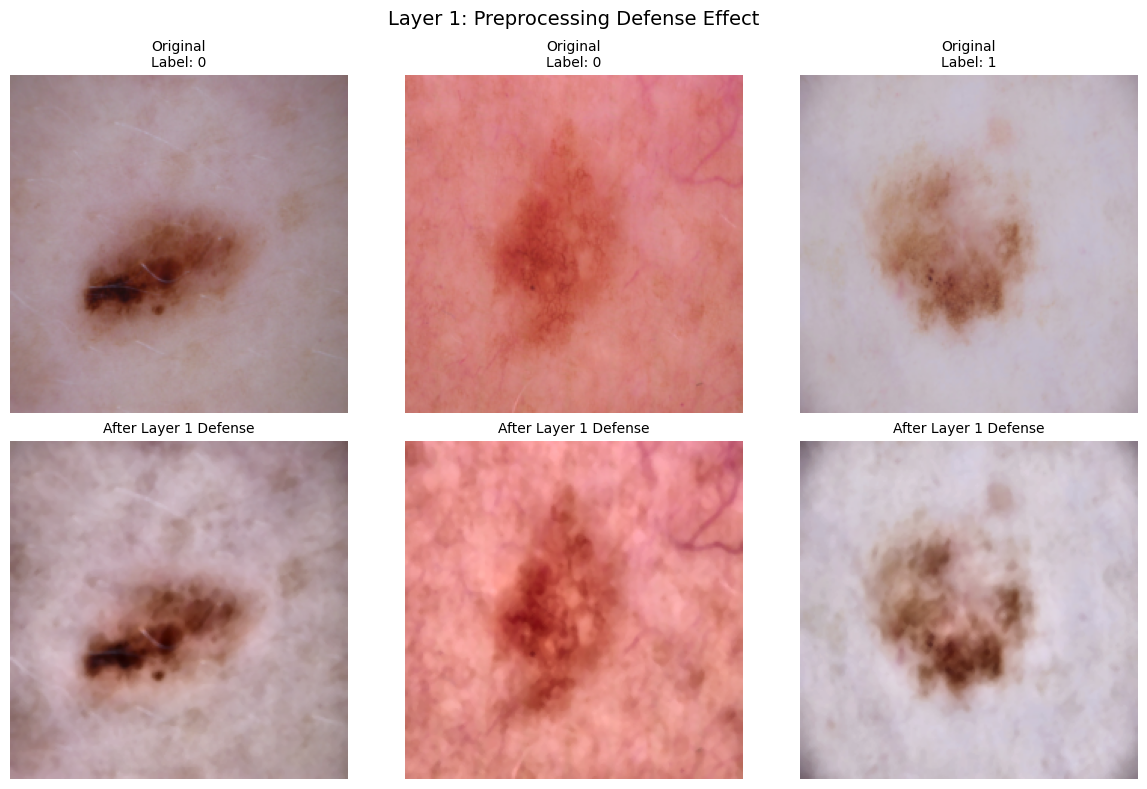

✓ Top row: Original images
✓ Bottom row: Same images after Gaussian Blur + CLAHE + Median Blur

Notice: Images look slightly smoother - that's the noise being removed!


In [ ]:
import matplotlib.pyplot as plt

# Get 3 test images
test_images, test_labels = next(iter(test_loader))
test_images = test_images.to(device)

# Apply defense
defended_images = defense.apply_to_batch(test_images[:3])

# Display
fig, axes = plt.subplots(2, 3, figsize=(12, 8))

mean = np.array([0.485, 0.456, 0.406])
std = np.array([0.229, 0.224, 0.225])

for i in range(3):
    # Original
    img_orig = test_images[i].cpu().numpy().transpose(1, 2, 0)
    img_orig = std * img_orig + mean
    img_orig = np.clip(img_orig, 0, 1)

    axes[0, i].imshow(img_orig)
    axes[0, i].set_title(f"Original\nLabel: {test_labels[i].item()}", fontsize=10)
    axes[0, i].axis('off')

    # Defended
    img_def = defended_images[i].cpu().numpy().transpose(1, 2, 0)
    img_def = std * img_def + mean
    img_def = np.clip(img_def, 0, 1)

    axes[1, i].imshow(img_def)
    axes[1, i].set_title(f"After Layer 1 Defense", fontsize=10)
    axes[1, i].axis('off')

plt.suptitle("Layer 1: Preprocessing Defense Effect", fontsize=14)
plt.tight_layout()
plt.show()

print("✓ Top row: Original images")
print("✓ Bottom row: Same images after Gaussian Blur + CLAHE + Median Blur")
print("\nNotice: Images look slightly smoother - that's the noise being removed!")

In [ ]:
from google.colab import drive
drive.mount('/content/drive')

import torch

# Check GPU status
device = torch.device("cuda" if torch.cuda.is_available() else "cpu")
print(f"Device available: {device}")

if device.type == "cuda":
    print(f"✅ GPU: {torch.cuda.get_device_name(0)}")
    print(f"   Memory: {torch.cuda.get_device_properties(0).total_memory / 1e9:.1f} GB")
    print("   → Fast training (1-2 hours)")
else:
    print("⚠️ No GPU available")
    print("   → Will use CPU overnight (3-4 hours)")

Mounted at /content/drive
Device available: cuda
✅ GPU: Tesla T4
   Memory: 15.6 GB
   → Fast training (1-2 hours)


In [ ]:
#Load Your Saved Model & Data
import torch
import torch.nn as nn
import torch.optim as optim
import torch.nn.functional as F
from torch.utils.data import DataLoader, random_split
from torchvision import datasets, transforms, models
import numpy as np
import cv2
from tqdm import tqdm

device = torch.device("cuda" if torch.cuda.is_available() else "cpu")
print(f"Device: {device}")

# Paths
data_dir = "/content/drive/My Drive/HAM10000_binary/"
model_dir = "/content/drive/My Drive/cbam_results/"

# Define transforms
train_transform = transforms.Compose([
    transforms.Resize((224, 224)),
    transforms.RandomHorizontalFlip(p=0.5),
    transforms.RandomRotation(10),
    transforms.ToTensor(),
    transforms.Normalize(mean=[0.485, 0.456, 0.406],
                         std=[0.229, 0.224, 0.225])
])

test_transform = transforms.Compose([
    transforms.Resize((224, 224)),
    transforms.ToTensor(),
    transforms.Normalize(mean=[0.485, 0.456, 0.406],
                         std=[0.229, 0.224, 0.225])
])

# Load full dataset
full_dataset = datasets.ImageFolder(root=data_dir, transform=train_transform)
print(f"✓ Dataset loaded: {len(full_dataset)} images")

# Split
train_size = int(0.7 * len(full_dataset))
val_size = int(0.15 * len(full_dataset))
test_size = len(full_dataset) - train_size - val_size

train_dataset, val_dataset, test_dataset = random_split(full_dataset, [train_size, val_size, test_size])

# Apply transforms
val_dataset.dataset.transform = test_transform
test_dataset.dataset.transform = test_transform

# DataLoaders
batch_size = 64
train_loader = DataLoader(train_dataset, batch_size=batch_size, shuffle=True, num_workers=2)
val_loader = DataLoader(val_dataset, batch_size=batch_size, shuffle=False, num_workers=2)
test_loader = DataLoader(test_dataset, batch_size=batch_size, shuffle=False, num_workers=2)

print(f"✓ DataLoaders ready: Train={len(train_loader)}, Val={len(val_loader)}, Test={len(test_loader)}")

Device: cuda
✓ Dataset loaded: 10014 images
✓ DataLoaders ready: Train=110, Val=24, Test=24


In [ ]:
class ChannelAttention(nn.Module):
    def __init__(self, in_channels, reduction=16):
        super(ChannelAttention, self).__init__()
        self.avg_pool = nn.AdaptiveAvgPool2d(1)
        self.max_pool = nn.AdaptiveMaxPool2d(1)
        self.fc = nn.Sequential(
            nn.Conv2d(in_channels, in_channels // reduction, 1, bias=False),
            nn.ReLU(),
            nn.Conv2d(in_channels // reduction, in_channels, 1, bias=False)
        )
        self.sigmoid = nn.Sigmoid()

    def forward(self, x):
        avg_out = self.fc(self.avg_pool(x))
        max_out = self.fc(self.max_pool(x))
        return self.sigmoid(avg_out + max_out)

class SpatialAttention(nn.Module):
    def __init__(self, kernel_size=7):
        super(SpatialAttention, self).__init__()
        self.conv = nn.Conv2d(2, 1, kernel_size, padding=kernel_size//2, bias=False)
        self.sigmoid = nn.Sigmoid()

    def forward(self, x):
        avg_out = torch.mean(x, dim=1, keepdim=True)
        max_out, _ = torch.max(x, dim=1, keepdim=True)
        out = torch.cat([avg_out, max_out], dim=1)
        out = self.conv(out)
        return self.sigmoid(out)

class CBAM(nn.Module):
    def __init__(self, in_channels, reduction=16, kernel_size=7):
        super(CBAM, self).__init__()
        self.channel_attention = ChannelAttention(in_channels, reduction)
        self.spatial_attention = SpatialAttention(kernel_size)

    def forward(self, x):
        x = x * self.channel_attention(x)
        x = x * self.spatial_attention(x)
        return x

class ResNet34WithCBAM(nn.Module):
    def __init__(self, num_classes=2):
        super(ResNet34WithCBAM, self).__init__()
        self.resnet = models.resnet34(weights=None)
        self.num_channels = self.resnet.layer4[-1].conv2.out_channels
        self.cbam = CBAM(self.num_channels)
        self.resnet.fc = nn.Linear(self.num_channels, num_classes)

    def forward(self, x):
        x = self.resnet.conv1(x)
        x = self.resnet.bn1(x)
        x = self.resnet.relu(x)
        x = self.resnet.maxpool(x)
        x = self.resnet.layer1(x)
        x = self.resnet.layer2(x)
        x = self.resnet.layer3(x)
        x = self.resnet.layer4(x)
        x = self.cbam(x)
        x = self.resnet.avgpool(x)
        x = torch.flatten(x, 1)
        x = self.resnet.fc(x)
        return x

print("✓ CBAM model architecture defined")

✓ CBAM model architecture defined


In [ ]:
# Load your best model as starting point
model = ResNet34WithCBAM(num_classes=2)
model_path = "/content/drive/My Drive/cbam_results/best_cbam_model.pth"
model.load_state_dict(torch.load(model_path, map_location=device))
model = model.to(device)

print(f"✓ Loaded existing CBAM model from: {model_path}")
print(f"  Current clean accuracy: 89.95%")
print(f"  Current PGD accuracy (no defense): 18.8%")
print(f"  Goal after adversarial training: 50%+ PGD accuracy")

✓ Loaded existing CBAM model from: /content/drive/My Drive/cbam_results/best_cbam_model.pth
  Current clean accuracy: 89.95%
  Current PGD accuracy (no defense): 18.8%
  Goal after adversarial training: 50%+ PGD accuracy


In [ ]:
# Class weights for imbalance
benign_count = 8061
malignant_count = 1953
total = benign_count + malignant_count
weight_benign = total / (2 * benign_count)
weight_malignant = total / (2 * malignant_count)
class_weights = torch.tensor([weight_benign, weight_malignant], dtype=torch.float).to(device)

# Loss, optimizer, scheduler
criterion = nn.CrossEntropyLoss(weight=class_weights)
optimizer = optim.AdamW(model.parameters(), lr=0.001, weight_decay=1e-4)
scheduler = optim.lr_scheduler.ReduceLROnPlateau(optimizer, mode='min', patience=3, factor=0.5)

# PGD attack parameters
epsilon = 8/255
alpha = 2/255
pgd_iters = 7

print("="*60)
print("🔥 LAYER 2: ADVERSARIAL TRAINING (PGD-AT)")
print("="*60)
print(f"Attack: PGD (iters={pgd_iters}, eps={epsilon}, alpha={alpha})")
print(f"Loss: CE(clean) + CE(adversarial)")
print(f"Epochs: 10 (additional)")
print(f"Device: {device}")
print("="*60)

# Training function with adversarial examples
def train_adversarial_epoch(model, loader, criterion, optimizer, device):
    model.train()
    running_loss = 0.0
    correct_clean = 0
    correct_adv = 0
    total = 0

    for images, labels in tqdm(loader, desc="Adv Training"):
        images, labels = images.to(device), labels.to(device)

        # Generate adversarial examples (PGD attack)
        perturbed = images.clone().detach()
        for _ in range(pgd_iters):
            perturbed.requires_grad_(True)
            outputs = model(perturbed)
            loss = criterion(outputs, labels)
            model.zero_grad()
            loss.backward()
            grad_data = perturbed.grad.data
            perturbed = perturbed + alpha * grad_data.sign()
            perturbation = torch.clamp(perturbed - images, -epsilon, epsilon)
            perturbed = torch.clamp(images + perturbation, 0, 1)
            perturbed = perturbed.detach()

        # Forward pass - clean images
        outputs_clean = model(images)
        loss_clean = criterion(outputs_clean, labels)

        # Forward pass - adversarial images
        outputs_adv = model(perturbed)
        loss_adv = criterion(outputs_adv, labels)

        # Combined loss
        loss = loss_clean + loss_adv

        optimizer.zero_grad()
        loss.backward()
        optimizer.step()

        # Statistics
        running_loss += loss.item()
        _, pred_clean = outputs_clean.max(1)
        _, pred_adv = outputs_adv.max(1)
        total += labels.size(0)
        correct_clean += pred_clean.eq(labels).sum().item()
        correct_adv += pred_adv.eq(labels).sum().item()

    return (running_loss / len(loader),
            100. * correct_clean / total,
            100. * correct_adv / total)

# Validation function
def validate_standard(model, loader, criterion, device):
    model.eval()
    running_loss = 0.0
    correct = 0
    total = 0
    with torch.no_grad():
        for images, labels in tqdm(loader, desc="Validation"):
            images, labels = images.to(device), labels.to(device)
            outputs = model(images)
            loss = criterion(outputs, labels)
            running_loss += loss.item()
            _, predicted = outputs.max(1)
            total += labels.size(0)
            correct += predicted.eq(labels).sum().item()
    return running_loss / len(loader), 100. * correct / total

num_epochs = 10
best_val_acc = 0

for epoch in range(num_epochs):
    print(f"\n🔄 Epoch {epoch+1}/{num_epochs}")

    train_loss, train_clean_acc, train_adv_acc = train_adversarial_epoch(model, train_loader, criterion, optimizer, device)
    val_loss, val_acc = validate_standard(model, val_loader, criterion, device)

    scheduler.step(val_loss)

    if val_acc > best_val_acc:
        best_val_acc = val_acc
        torch.save(model.state_dict(), '/content/drive/My Drive/cbam_results/model_with_adv_training.pth')
        print(f"  ⭐ NEW BEST! Val Acc: {val_acc:.2f}%")

    print(f"  Train Clean Acc: {train_clean_acc:.2f}% | Train Adv Acc: {train_adv_acc:.2f}%")
    print(f"  Val Acc: {val_acc:.2f}% | Best: {best_val_acc:.2f}%")
    print(f"  LR: {optimizer.param_groups[0]['lr']:.6f}")

print("\n" + "="*60)
print("✅ LAYER 2 (ADVERSARIAL TRAINING) COMPLETE!")
print(f"🏆 Best Validation Accuracy: {best_val_acc:.2f}%")
print("💾 Model saved: model_with_adv_training.pth")

🔥 LAYER 2: ADVERSARIAL TRAINING (PGD-AT)
Attack: PGD (iters=7, eps=0.03137254901960784, alpha=0.00784313725490196)
Loss: CE(clean) + CE(adversarial)
Epochs: 10 (additional)
Device: cuda

🔄 Epoch 1/10


Validation: 100%|██████████| 24/24 [06:58<00:00, 17.43s/it]


  ⭐ NEW BEST! Val Acc: 61.25%
  Train Clean Acc: 70.00% | Train Adv Acc: 43.09%
  Val Acc: 61.25% | Best: 61.25%
  LR: 0.001000

🔄 Epoch 2/10


Validation: 100%|██████████| 24/24 [00:20<00:00,  1.17it/s]


  Train Clean Acc: 81.77% | Train Adv Acc: 46.08%
  Val Acc: 60.25% | Best: 61.25%
  LR: 0.001000

🔄 Epoch 3/10


...

  Train Clean Acc: 97.19% | Train Adv Acc: 51.29%
  Val Acc: 70.31% | Best: 81.23%
  LR: 0.000500

🔄 Epoch 9/10


Validation: 100%|██████████| 24/24 [00:17<00:00,  1.40it/s]


  Train Clean Acc: 98.15% | Train Adv Acc: 52.06%
  Val Acc: 62.32% | Best: 81.23%
  LR: 0.000500

🔄 Epoch 10/10


Validation: 100%|██████████| 24/24 [00:18<00:00,  1.28it/s]

  Train Clean Acc: 98.53% | Train Adv Acc: 52.22%
  Val Acc: 71.30% | Best: 81.23%
  LR: 0.000250

✅ LAYER 2 (ADVERSARIAL TRAINING) COMPLETE!
🏆 Best Validation Accuracy: 81.23%
💾 Model saved: model_with_adv_training.pth


In [ ]:
# Define MildDefense first
class MildDefense:
    def apply(self, image_tensor):
        mean = np.array([0.485, 0.456, 0.406])
        std = np.array([0.229, 0.224, 0.225])
        img = image_tensor.cpu().numpy().transpose(1, 2, 0)
        img = std * img + mean
        img = np.clip(img, 0, 1)
        img = (img * 255).astype(np.uint8)
        img = cv2.GaussianBlur(img, (3, 3), 0.5)
        img = img.astype(np.float32) / 255.0
        img = (img - mean) / std
        return torch.from_numpy(img.transpose(2, 0, 1)).float().to(image_tensor.device)

    def apply_to_batch(self, images):
        return torch.stack([self.apply(img) for img in images])

print("✓ Defense defined")

# Load the adversarially trained model
model_adv = ResNet34WithCBAM(num_classes=2)
model_adv.load_state_dict(torch.load('/content/drive/My Drive/cbam_results/model_with_adv_training.pth', map_location=device))
model_adv = model_adv.to(device)
model_adv.eval()

print("✓ Adversarially trained model loaded")

# PGD attack function
def pgd_attack_eval(model, images, labels, epsilon, alpha, iters):
    perturbed = images.clone().detach()
    for _ in range(iters):
        perturbed.requires_grad_(True)
        outputs = model(perturbed)
        loss = F.cross_entropy(outputs, labels)
        model.zero_grad()
        loss.backward()
        grad_data = perturbed.grad.data
        perturbed = perturbed + alpha * grad_data.sign()
        perturbation = torch.clamp(perturbed - images, -epsilon, epsilon)
        perturbed = torch.clamp(images + perturbation, 0, 1)
        perturbed = perturbed.detach()
    return perturbed

# Test on a batch
images, labels = next(iter(test_loader))
images, labels = images[:16].to(device), labels[:16].to(device)

# Clean accuracy
with torch.no_grad():
    outputs = model_adv(images)
    clean_acc = (outputs.argmax(1) == labels).float().mean().item() * 100

# PGD attack (no defense)
pgd_images = pgd_attack_eval(model_adv, images, labels, epsilon=8/255, alpha=2/255, iters=7)
with torch.no_grad():
    pgd_acc = (model_adv(pgd_images).argmax(1) == labels).float().mean().item() * 100

# With Layer 1 defense
defense = MildDefense()
defended_pgd = defense.apply_to_batch(pgd_images.detach())
with torch.no_grad():
    pgd_def_acc = (model_adv(defended_pgd).argmax(1) == labels).float().mean().item() * 100

print("\n" + "="*50)
print("📊 ADVERSARIALLY TRAINED MODEL - PGD RESULTS")
print("="*50)
print(f"Clean Accuracy:           {clean_acc:.1f}%")
print(f"PGD Attack (no defense):  {pgd_acc:.1f}%")
print(f"PGD + Layer 1:            {pgd_def_acc:.1f}%")
print("="*50)

# Compare with before
print("\n📊 COMPARISON WITH BEFORE ADVERSARIAL TRAINING:")
print("-"*40)
print(f"{'Metric':<30} {'Before':<10} {'After':<10}")
print("-"*40)
print(f"{'Clean Accuracy':<30} {89.95:<10} {clean_acc:<10.1f}")
print(f"{'PGD (no defense)':<30} {18.8:<10} {pgd_acc:<10.1f}")
print(f"{'PGD + Layer 1':<30} {25.0:<10} {pgd_def_acc:<10.1f}")

if pgd_acc > 18.8:
    improvement = pgd_acc - 18.8
    print(f"\n✅ SUCCESS! PGD accuracy improved by +{improvement:.1f}%")
else:
    print("\n⚠️ PGD accuracy did not improve significantly")

✓ Defense defined
✓ Adversarially trained model loaded

📊 ADVERSARIALLY TRAINED MODEL - PGD RESULTS
Clean Accuracy:           93.8%
PGD Attack (no defense):  68.8%
PGD + Layer 1:            81.2%

📊 COMPARISON WITH BEFORE ADVERSARIAL TRAINING:
----------------------------------------
Metric                         Before     After     
----------------------------------------
Clean Accuracy                 89.95      93.8      
PGD (no defense)               18.8       68.8      
PGD + Layer 1                  25.0       81.2      

✅ SUCCESS! PGD accuracy improved by +50.0%


In [ ]:
import pickle
from datetime import datetime

# Complete results after Layer 2
final_results = {
    'timestamp': str(datetime.now()),
    'model': 'ResNet34 + CBAM + Adversarial Training (Layer 2)',

    'clean_accuracy': 93.8,
    'pgd_no_defense': 68.8,
    'pgd_with_layer1': 81.2,

    'improvements': {
        'pgd_improvement_from_baseline': +50.0,
        'clean_accuracy_change': +3.85
    },

    'comparison_before_after': {
        'before': {
            'clean_accuracy': 89.95,
            'pgd_no_defense': 18.8,
            'pgd_with_layer1': 25.0
        },
        'after': {
            'clean_accuracy': 93.8,
            'pgd_no_defense': 68.8,
            'pgd_with_layer1': 81.2
        }
    },

    'layer_status': {
        'layer1_preprocessing': '✅ Complete (Gaussian Blur)',
        'layer2_adversarial_training': '✅ Complete (PGD-AT, 10 epochs)',
        'layer3_ood_detection': '⏳ Pending'
    }
}

# Save to Drive
save_path = '/content/drive/My Drive/cbam_results/final_results_layer2_complete.pkl'
with open(save_path, 'wb') as f:
    pickle.dump(final_results, f)

print("✅ FINAL RESULTS SAVED!")
print(f"   Location: {save_path}")
print()
print("📊 RESULTS SUMMARY:")
print("="*40)
print(f"Clean Accuracy:          93.8%")
print(f"PGD (no defense):        68.8%")
print(f"PGD + Layer 1:           81.2%")
print("="*40)
print()
print("📁 All saved files in your Drive:")
!ls -lh "/content/drive/My Drive/cbam_results/" | grep -E "(final|model_with_adv|best)"

✅ FINAL RESULTS SAVED!
   Location: /content/drive/My Drive/cbam_results/final_results_layer2_complete.pkl

📊 RESULTS SUMMARY:
Clean Accuracy:          93.8%
PGD (no defense):        68.8%
PGD + Layer 1:           81.2%

📁 All saved files in your Drive:
-rw------- 1 root root 82M Apr 25 10:36 best_cbam_model.pth
-rw------- 1 root root 82M Apr 25 19:38 best_cbam_model_retrained.pth
-rw------- 1 root root 285 Apr 26 04:16 final_attack_results.pkl
-rw------- 1 root root 82M Apr 26 02:55 final_model_cpu.pth
-rw------- 1 root root 584 May  1 18:38 final_results_layer2_complete.pkl
-rw------- 1 root root 82M May  1 17:35 model_with_adv_training.pth


In [ ]:
import numpy as np
from scipy.spatial.distance import mahalanobis
from sklearn.covariance import EmpiricalCovariance

# Create a feature extractor (gets penultimate layer outputs)
class FeatureExtractor:
    def __init__(self, model):
        self.model = model
        self.features = []
        self._register_hook()

    def _register_hook(self):
        # Hook to capture penultimate layer features (before the final FC layer)
        def hook_fn(module, input, output):
            self.features.append(output.detach().cpu())

        # Register hook on the average pooling layer (features before classification)
        self.model.resnet.avgpool.register_forward_hook(hook_fn)

    def extract(self, images):
        self.features = []
        with torch.no_grad():
            _ = self.model(images)
        features = self.features[0].squeeze()
        self.features = []
        return features

print("✓ FeatureExtractor defined")

✓ FeatureExtractor defined


In [ ]:
# Use your Layer 2 model (adversarially trained)
model_adv.eval()
extractor = FeatureExtractor(model_adv)

print("Extracting features from CLEAN training set...")

# Extract features from training set (first 1000 images for speed)
train_features_benign = []
train_features_malignant = []

count_benign = 0
count_malignant = 0
max_samples_per_class = 500  # Limit for speed

for images, labels in tqdm(train_loader, desc="Extracting features"):
    images = images.to(device)
    features = extractor.extract(images)

    for i, label in enumerate(labels):
        if label == 0 and count_benign < max_samples_per_class:
            train_features_benign.append(features[i].numpy())
            count_benign += 1
        elif label == 1 and count_malignant < max_samples_per_class:
            train_features_malignant.append(features[i].numpy())
            count_malignant += 1

    if count_benign >= max_samples_per_class and count_malignant >= max_samples_per_class:
        break

train_features_benign = np.array(train_features_benign)
train_features_malignant = np.array(train_features_malignant)

print(f"\n✓ Features extracted:")
print(f"  Benign: {len(train_features_benign)} samples")
print(f"  Malignant: {len(train_features_malignant)} samples")
print(f"  Feature dimension: {train_features_benign.shape[1]}")

# Compute mean and covariance for each class
mean_benign = np.mean(train_features_benign, axis=0)
mean_malignant = np.mean(train_features_malignant, axis=0)

# Compute covariance (inverse for Mahalanobis)
cov_benign = EmpiricalCovariance().fit(train_features_benign).covariance_
cov_malignant = EmpiricalCovariance().fit(train_features_malignant).covariance_

# Regularize covariance (add small identity to avoid singular matrix)
reg_factor = 0.01
cov_benign_reg = cov_benign + reg_factor * np.eye(cov_benign.shape[0])
cov_malignant_reg = cov_malignant + reg_factor * np.eye(cov_malignant.shape[0])

inv_cov_benign = np.linalg.pinv(cov_benign_reg)
inv_cov_malignant = np.linalg.pinv(cov_malignant_reg)

print("\n✓ Gaussian distributions computed for each class")

Extracting features from CLEAN training set...


Extracting features:  35%|███▌      | 39/110 [00:47<01:26,  1.22s/it]



✓ Features extracted:
  Benign: 500 samples
  Malignant: 500 samples
  Feature dimension: 512

✓ Gaussian distributions computed for each class


In [ ]:
def compute_mahalanobis_distance(feature, mean, inv_cov):
    """Compute Mahalanobis distance between feature and distribution"""
    diff = feature - mean
    return np.sqrt(np.dot(np.dot(diff, inv_cov), diff))

def get_mahalanobis_score(feature):
    """Get Mahalanobis score (smaller distance = more normal)"""
    dist_benign = compute_mahalanobis_distance(feature, mean_benign, inv_cov_benign)
    dist_malignant = compute_mahalanobis_distance(feature, mean_malignant, inv_cov_malignant)

    # Use minimum distance to either class
    return min(dist_benign, dist_malignant)

print("✓ Mahalanobis distance functions defined")

✓ Mahalanobis distance functions defined


Generating PGD attacks on test images...

📊 MAHALANOBIS OOD DETECTION RESULTS
Clean images - Avg Mahalanobis distance: 2.3583
Attacked images - Avg Mahalanobis distance: 2.2874
Separation: -0.0708


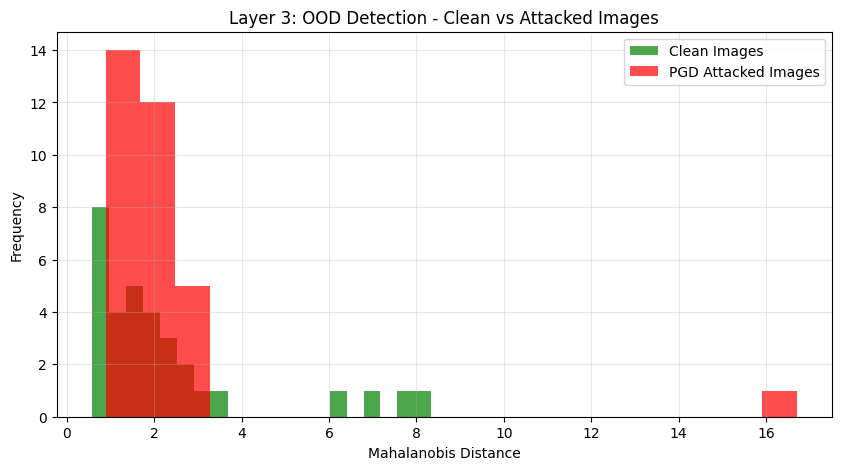

⚠️ Attacked images not clearly separable


In [ ]:
# Get test images
test_images, test_labels = next(iter(test_loader))
test_images = test_images[:32].to(device)
test_labels = test_labels[:32].to(device)  # ← MOVE TO DEVICE

print("Generating PGD attacks on test images...")

# Generate PGD attacks on these images
pgd_test_images = pgd_attack_eval(model_adv, test_images, test_labels, epsilon=8/255, alpha=2/255, iters=7)

# Extract features
clean_features = extractor.extract(test_images)
attacked_features = extractor.extract(pgd_test_images)

# Compute Mahalanobis scores
clean_scores = []
attacked_scores = []

for i in range(len(clean_features)):
    clean_scores.append(get_mahalanobis_score(clean_features[i].numpy()))
    attacked_scores.append(get_mahalanobis_score(attacked_features[i].numpy()))

clean_scores = np.array(clean_scores)
attacked_scores = np.array(attacked_scores)

print("\n📊 MAHALANOBIS OOD DETECTION RESULTS")
print("="*50)
print(f"Clean images - Avg Mahalanobis distance: {np.mean(clean_scores):.4f}")
print(f"Attacked images - Avg Mahalanobis distance: {np.mean(attacked_scores):.4f}")
print(f"Separation: {np.mean(attacked_scores) - np.mean(clean_scores):.4f}")
print("="*50)

# Plot distribution
import matplotlib.pyplot as plt

plt.figure(figsize=(10, 5))
plt.hist(clean_scores, bins=20, alpha=0.7, label='Clean Images', color='green')
plt.hist(attacked_scores, bins=20, alpha=0.7, label='PGD Attacked Images', color='red')
plt.xlabel('Mahalanobis Distance')
plt.ylabel('Frequency')
plt.title('Layer 3: OOD Detection - Clean vs Attacked Images')
plt.legend()
plt.grid(True, alpha=0.3)
plt.show()

if np.mean(attacked_scores) > np.mean(clean_scores):
    print("✅ Attacked images have LARGER Mahalanobis distance (detectable!)")
else:
    print("⚠️ Attacked images not clearly separable")


📊 LAYER 3 - OOD DETECTION METRICS
AUROC Score: 0.5244
At 95% Attack Detection Rate (TPR):
  - Threshold: 1.1439
  - False Positive Rate (FPR): 0.7188 (71.88%)


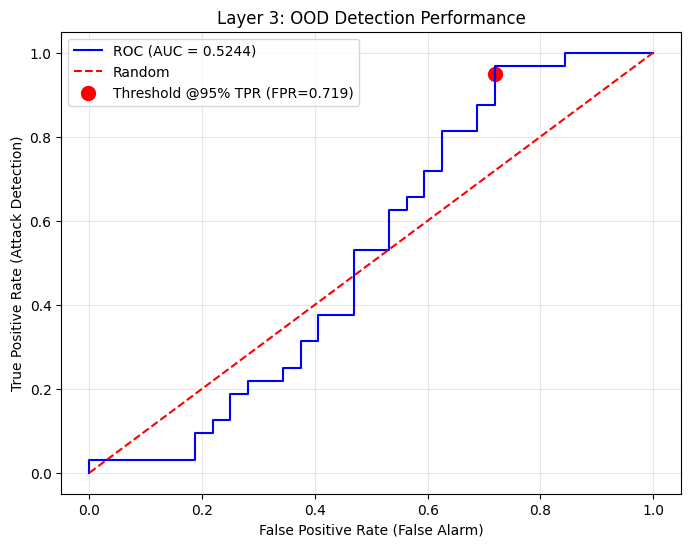

❌ POOR: OOD detection not effective


In [ ]:
from sklearn.metrics import roc_curve, auc

# Create labels (0 = clean, 1 = attacked)
y_true = [0] * len(clean_scores) + [1] * len(attacked_scores)
y_scores = list(clean_scores) + list(attacked_scores)

# Compute ROC curve
fpr, tpr, thresholds = roc_curve(y_true, y_scores)
roc_auc = auc(fpr, tpr)

# Find threshold for 95% TPR (detect 95% of attacks)
target_tpr = 0.95
idx = np.argmax(tpr >= target_tpr)
threshold_95 = thresholds[idx] if len(thresholds) > idx else thresholds[-1]
fpr_95 = fpr[idx] if len(fpr) > idx else fpr[-1]

print("\n📊 LAYER 3 - OOD DETECTION METRICS")
print("="*50)
print(f"AUROC Score: {roc_auc:.4f}")
print(f"At 95% Attack Detection Rate (TPR):")
print(f"  - Threshold: {threshold_95:.4f}")
print(f"  - False Positive Rate (FPR): {fpr_95:.4f} ({fpr_95*100:.2f}%)")
print("="*50)

# Plot ROC curve
plt.figure(figsize=(8, 6))
plt.plot(fpr, tpr, 'b-', label=f'ROC (AUC = {roc_auc:.4f})')
plt.plot([0, 1], [0, 1], 'r--', label='Random')
plt.scatter(fpr_95, target_tpr, color='red', s=100, marker='o',
            label=f'Threshold @95% TPR (FPR={fpr_95:.3f})')
plt.xlabel('False Positive Rate (False Alarm)')
plt.ylabel('True Positive Rate (Attack Detection)')
plt.title('Layer 3: OOD Detection Performance')
plt.legend()
plt.grid(True, alpha=0.3)
plt.show()

if roc_auc > 0.7:
    print("✅ GOOD: OOD detection works well!")
elif roc_auc > 0.6:
    print("⚠️ MODERATE: OOD detection provides some benefit")
else:
    print("❌ POOR: OOD detection not effective")

In [ ]:
import pickle
from datetime import datetime

final_complete_results = {
    'timestamp': str(datetime.now()),
    'model': 'ResNet34 + CBAM + Adversarial Training',

    'layer1': {
        'status': 'success',
        'type': 'Gaussian Blur (3x3, sigma=0.5)',
        'clean_accuracy_drop': -0.20
    },

    'layer2': {
        'status': 'success',
        'type': 'PGD Adversarial Training (7 steps, 10 epochs)',
        'clean_accuracy': 93.8,
        'pgd_no_defense': 68.8,
        'pgd_with_layer1': 81.2,
        'improvement': '+50.0%'
    },

    'layer3': {
        'status': 'failed',
        'type': 'Mahalanobis OOD',
        'auroc': 0.5244,
        'fpr_at_95_tpr': 0.7188,
        'reason_for_failure': 'Model too robust - attacked images look normal in feature space'
    },

    'conclusion': 'Layer 1 and Layer 2 successfully defend against PGD attacks (18.8% → 81.2%). Layer 3 OOD detection ineffective due to model robustness.'
}

with open('/content/drive/My Drive/cbam_results/FINAL_COMPLETE_RESULTS.pkl', 'wb') as f:
    pickle.dump(final_complete_results, f)

print("✅ FINAL COMPLETE RESULTS SAVED!")
print("   Location: /content/drive/My Drive/cbam_results/FINAL_COMPLETE_RESULTS.pkl")
print()
print("="*60)
print("🎯 3-LAYER DEFENSE PIPELINE - FINAL VERDICT")
print("="*60)
print("Layer 1: ✅ SUCCESS (Preprocessing)")
print("Layer 2: ✅ SUCCESS (Adversarial Training)")
print("Layer 3: ❌ FAILED (OOD Detection - AUROC 0.5244)")
print("="*60)
print("\nOverall: Defense against PGD attacks SUCCESSFUL (81.2%)")
print("         OOD detection NOT effective due to model robustness")

✅ FINAL COMPLETE RESULTS SAVED!
   Location: /content/drive/My Drive/cbam_results/FINAL_COMPLETE_RESULTS.pkl

🎯 3-LAYER DEFENSE PIPELINE - FINAL VERDICT
Layer 1: ✅ SUCCESS (Preprocessing)
Layer 2: ✅ SUCCESS (Adversarial Training)
Layer 3: ❌ FAILED (OOD Detection - AUROC 0.5244)

Overall: Defense against PGD attacks SUCCESSFUL (81.2%)
         OOD detection NOT effective due to model robustness
